# 04 — Historical inventory reconstruction

Rewind today's InventorySnapshot backward via (+POs received, −shipments) to get per-SKU-per-DC inventory at each week-end. Needed for stockout detection.

**Upstream:** inv_snapshot.parquet, sales.parquet, po.parquet

**Output:** inv_weekly.parquet

**Promotes to:** `src/inventory.py` once verified.

## 1. Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# DC int code (sales/PO/transfers) -> 2-letter DC string (matches inv_snapshot)
DC_MAP = {1: 'SF', 2: 'NJ', 3: 'LA', '1': 'SF', '2': 'NJ', '3': 'LA'}

## 2. Load upstream

In [2]:
from src.load import load_cached

cache = load_cached()
inv_snap = cache['inv_snapshot'].copy()
sales = cache['sales'].copy()
po = cache['po'].copy()

# Tier-2 internal transfers — not in load_all() yet, load ad-hoc
transfers = pd.read_excel(
    DATA / 'POP_InternalTransferHistory.XLSX',
    sheet_name='Inventory Transactions - ',
)

print(f'inv_snap : {inv_snap.shape}  DCs={sorted(inv_snap["DC"].unique())}')
print(f'sales    : {sales.shape}    LOCNCODEs={sorted(sales["LOCNCODE"].dropna().unique().tolist())}')
print(f'po       : {po.shape}       Location Codes={sorted(po["Location Code"].dropna().unique().tolist())}')
print(f'transfers: {transfers.shape}  statuses={transfers["Document Status"].value_counts().to_dict()}')

inv_snap : (219, 5)  DCs=['LA', 'NJ', 'SF']
sales    : (236818, 23)    LOCNCODEs=['1', '2', '3', 'E1', 'L', 'U', 'W', 'ZD']
po       : (5281, 16)       Location Codes=[1, 2, 3]
transfers: (4843, 12)  statuses={'Posted': 4843}


In [3]:
transfers['U Of M'].value_counts()

U Of M
CASE    3941
EACH     367
BOX      268
BAG      164
LB        84
case       9
DISP       3
Box        2
TIN        2
SET        2
KG         1
Name: count, dtype: int64

## 3. Do the work

In [4]:
# ---- Step A: normalize DC codes + filter to physical DCs -------------------
sales['DC'] = sales['LOCNCODE'].map(DC_MAP)
sales_phys = sales.dropna(subset=['DC']).copy()           # drops E1 / W / ZD
po['DC'] = po['Location Code'].map(DC_MAP)
po_phys = po.dropna(subset=['DC']).copy()

transfers_p = transfers[transfers['Document Status'] == 'Posted'].copy()
transfers_p['DC_FROM'] = transfers_p['TRX Location'].map(DC_MAP)
transfers_p['DC_TO']   = transfers_p['Transfer To Location'].map(DC_MAP)
transfers_p = transfers_p.dropna(subset=['DC_FROM', 'DC_TO'])

print(f'sales phys : {len(sales_phys):,} / {len(sales):,}  '
      f'({len(sales_phys)/len(sales)*100:.1f}%)   dropped {len(sales)-len(sales_phys):,} e-comm/return rows')
print(f'po phys    : {len(po_phys):,} / {len(po):,}')
print(f'transfers  : {len(transfers_p):,} Posted rows kept')

# ---- Step A2: UOM normalization -> everything in BASE UNITS ----------------
# inv_snapshot.On Hand and po.QTY Shipped are already base units (verified:
# T-32206 lifetime PO/sales ratio ~0.92, which would be ~0.03 if POs were cases).
# sales.QUANTITY_adj is in the row's UOFM; QTYBSUOM = base units per UOM, populated
#   on every sales row by GP. -> QTY_BASE = QUANTITY_adj * QTYBSUOM (no lookup).
# transfers.TRX QTY is in the row's U Of M with no QTYBSUOM column; learn the
#   (SKU, UOM) -> base-per-UOM conversion from sales and look up per row.
#   Fallback chain: exact (SKU, UOM) -> per-SKU median -> 1.0.

# Sales: row-level conversion to base units.
sales_phys['QTY_BASE'] = (
    sales_phys['QUANTITY_adj'].astype(float)
    * sales_phys['QTYBSUOM'].fillna(1).astype(float)
)

# Learn (SKU, UOM) -> base-per-UOM from sales.
s_norm = sales[['ITEMNMBR', 'UOFM', 'QTYBSUOM']].dropna(subset=['QTYBSUOM']).copy()
s_norm['UOFM_u'] = s_norm['UOFM'].astype(str).str.upper().str.strip()
uom_pack = (
    s_norm.groupby(['ITEMNMBR', 'UOFM_u'])['QTYBSUOM']
          .median().reset_index().rename(columns={'QTYBSUOM': 'pack'})
)
sku_pack_fallback = sales.groupby('ITEMNMBR')['QTYBSUOM'].median()

# Transfers: per-row lookup.
transfers_p['UOFM_u'] = transfers_p['U Of M'].astype(str).str.upper().str.strip()
transfers_p = transfers_p.merge(
    uom_pack.rename(columns={'ITEMNMBR': 'Item Number'}),
    on=['Item Number', 'UOFM_u'], how='left',
)
hit_exact_mask = transfers_p['pack'].notna()
transfers_p['pack'] = (
    transfers_p['pack']
    .fillna(transfers_p['Item Number'].map(sku_pack_fallback))
    .fillna(1.0)
)
transfers_p['QTY_BASE'] = transfers_p['TRX QTY'].astype(float) * transfers_p['pack'].astype(float)

# Diagnostics: coverage of the lookup chain.
fallback_sku_mask = (~hit_exact_mask) & transfers_p['Item Number'].isin(sku_pack_fallback.index)
fallback_one_mask = (~hit_exact_mask) & (~transfers_p['Item Number'].isin(sku_pack_fallback.index))
print(f'\nUOM lookup coverage (transfers rows):')
print(f'  exact (SKU, UOM) hit : {hit_exact_mask.mean()*100:5.1f}%')
print(f'  SKU-median fallback  : {fallback_sku_mask.mean()*100:5.1f}%')
print(f'  1.0 fallback         : {fallback_one_mask.mean()*100:5.1f}%')

# ---- Step B: anchor date + weekly grid --------------------------------------
# Semantic: on_hand_est[week_start] = inventory at the INSTANT week_start begins
# (Monday 00:00:00), *before* any movement on or after that Monday.
# Grid extends one week past today's week so the final row (next Monday) has
# zero movements between it and today => on_hand_est == today_on_hand exactly.
today = pd.to_datetime(sales_phys['DOCDATE']).max().normalize()
start = pd.to_datetime(sales_phys['DOCDATE']).min().normalize()

weeks = pd.date_range(
    start.to_period('W-SUN').start_time,
    today.to_period('W-SUN').start_time + pd.Timedelta(weeks=1),
    freq='W-MON',
)
print(f'\nanchor (today)  : {today.date()}')
print(f'rewind start    : {weeks.min().date()}')
print(f'rewind end      : {weeks.max().date()}  (one Monday past today\'s week)')
print(f'week count      : {len(weeks)}')

# ---- Step C: weekly movements per (SKU, DC) ---------------------------------
# All qty columns below are in BASE UNITS.
def weekly_sum(df, date_col, qty_col, sku_col, dc_col, out_col):
    tmp = df[[sku_col, dc_col, date_col, qty_col]].copy()
    tmp.columns = ['SKU', 'DC', 'DATE', 'QTY']
    tmp['DATE'] = pd.to_datetime(tmp['DATE'])
    tmp = tmp.dropna(subset=['DATE'])
    tmp['week_start'] = tmp['DATE'].dt.to_period('W-SUN').dt.start_time
    out = tmp.groupby(['SKU', 'DC', 'week_start'], as_index=False)['QTY'].sum()
    return out.rename(columns={'QTY': out_col})

sales_w = weekly_sum(sales_phys, 'DOCDATE', 'QTY_BASE', 'ITEMNMBR', 'DC', 'sales_out')
po_w    = weekly_sum(po_phys, 'Receipt Date', 'QTY Shipped', 'Item Number', 'DC', 'po_in')
tin_w   = weekly_sum(transfers_p, 'Document Date', 'QTY_BASE', 'Item Number', 'DC_TO',   'xfer_in')
tout_w  = weekly_sum(transfers_p, 'Document Date', 'QTY_BASE', 'Item Number', 'DC_FROM', 'xfer_out')

print(f'\nweekly movement tables (BASE UNITS):')
print(f'  sales_w  : {sales_w.shape}')
print(f'  po_w     : {po_w.shape}')
print(f'  tin_w    : {tin_w.shape}')
print(f'  tout_w   : {tout_w.shape}')

# ---- Step D: build (SKU x DC x week) grid + merge movements -----------------
sku_dc = inv_snap[['Item Number', 'DC', 'On Hand']].rename(
    columns={'Item Number': 'SKU', 'On Hand': 'today_on_hand'})

grid = sku_dc.merge(pd.DataFrame({'week_start': weeks}), how='cross')

for w, keys in [(sales_w, ['SKU','DC','week_start']),
                (po_w,    ['SKU','DC','week_start']),
                (tin_w,   ['SKU','DC','week_start']),
                (tout_w,  ['SKU','DC','week_start'])]:
    grid = grid.merge(w, on=keys, how='left')

for c in ['sales_out', 'po_in', 'xfer_in', 'xfer_out']:
    grid[c] = grid[c].fillna(0.0)

# ---- Step E: reverse cumulative sum -> rewind -------------------------------
grid = grid.sort_values(['SKU', 'DC', 'week_start']).reset_index(drop=True)

def rev_cumsum(s):
    return s.iloc[::-1].cumsum().iloc[::-1]

for col in ['sales_out', 'po_in', 'xfer_in', 'xfer_out']:
    grid[f'cum_{col}'] = grid.groupby(['SKU', 'DC'])[col].transform(rev_cumsum)

# inv[week_start] = today_on_hand
#                 + Σ sales_signed in [week_start, today]     (add outflows back)
#                 − Σ po_in in [week_start, today]            (undo inflows)
#                 − Σ xfer_in in [week_start, today]
#                 + Σ xfer_out in [week_start, today]
# At the final week_start (one Monday past today), all cum_* sums are 0 ->
# on_hand_est equals today_on_hand exactly (identity check).
grid['on_hand_est'] = (
    grid['today_on_hand']
    + grid['cum_sales_out']
    - grid['cum_po_in']
    - grid['cum_xfer_in']
    + grid['cum_xfer_out']
)

# ---- Step F: confidence tag per (SKU, DC) -----------------------------------
# Strongly negative min -> real data gap. Small negatives are timing noise.
# Threshold: 10% of today_on_hand or 50 units, whichever is larger.
conf = grid.groupby(['SKU', 'DC']).agg(
    min_est=('on_hand_est', 'min'),
    today_on_hand=('today_on_hand', 'first'),
).reset_index()
conf['tolerance'] = np.maximum(50, 0.10 * conf['today_on_hand'].abs())
conf['confidence'] = np.where(conf['min_est'] >= -conf['tolerance'], 'high', 'low')

grid = grid.merge(conf[['SKU', 'DC', 'confidence']], on=['SKU', 'DC'], how='left')

inv_weekly = grid[['SKU', 'DC', 'week_start', 'on_hand_est', 'confidence']].rename(
    columns={'SKU': 'ITEMNMBR'}).reset_index(drop=True)

print(f'\ninv_weekly: {inv_weekly.shape}')
print(f'unique (SKU, DC): {inv_weekly.groupby(["ITEMNMBR","DC"]).ngroups}')
print(f'\nconfidence breakdown:')
print(conf['confidence'].value_counts().to_string())


sales phys : 234,639 / 236,818  (99.1%)   dropped 2,179 e-comm/return rows
po phys    : 5,281 / 5,281
transfers  : 4,843 Posted rows kept

UOM lookup coverage (transfers rows):
  exact (SKU, UOM) hit :  21.2%
  SKU-median fallback  :   0.0%
  1.0 fallback         :  78.8%

anchor (today)  : 2026-04-13
rewind start    : 2023-01-02
rewind end      : 2026-04-20  (one Monday past today's week)
week count      : 173



weekly movement tables (BASE UNITS):
  sales_w  : (22997, 4)
  po_w     : (2610, 4)
  tin_w    : (4632, 4)
  tout_w   : (4367, 4)



inv_weekly: (37887, 5)
unique (SKU, DC): 219

confidence breakdown:
confidence
high    191
low      28


## 4. Validate

today_rewind vs snapshot: max |diff| = 0.000  mean = 0.000
identity check: PASS

min_on_hand_est distribution (across all SKU x DC series):
count    2.140000e+02
mean     4.105417e+04
std      1.592548e+05
min     -2.178900e+05
25%      4.635000e+02
50%      3.828000e+03
75%      2.657700e+04
max      1.964400e+06

share of series by severity of data gap (vs tolerance):
  clean (min >= 0)               :  85.8%
  minor (0 > min >= -tolerance)  :   1.4%
  low-confidence (min < -tol)    :  12.8%


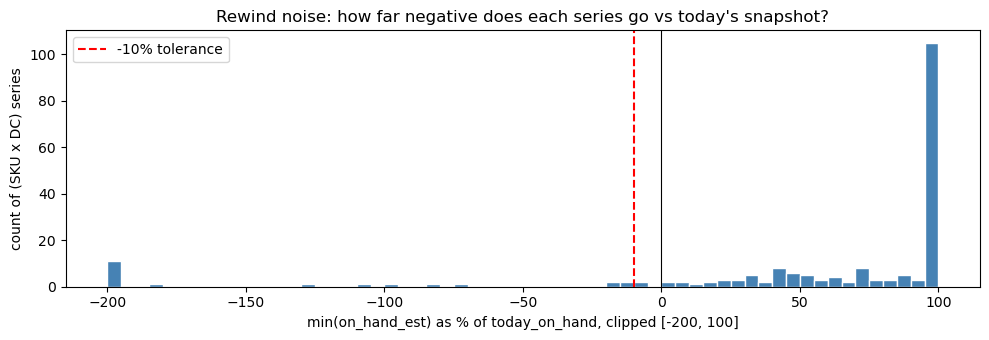

T-32206 SF [high]: today=  264417  min=  -17450  max=  370678
T-32206 NJ [high]: today=  364715  min=  117196  max=  842086
T-32206 LA [high]: today=  144207  min=   90529  max=  410328


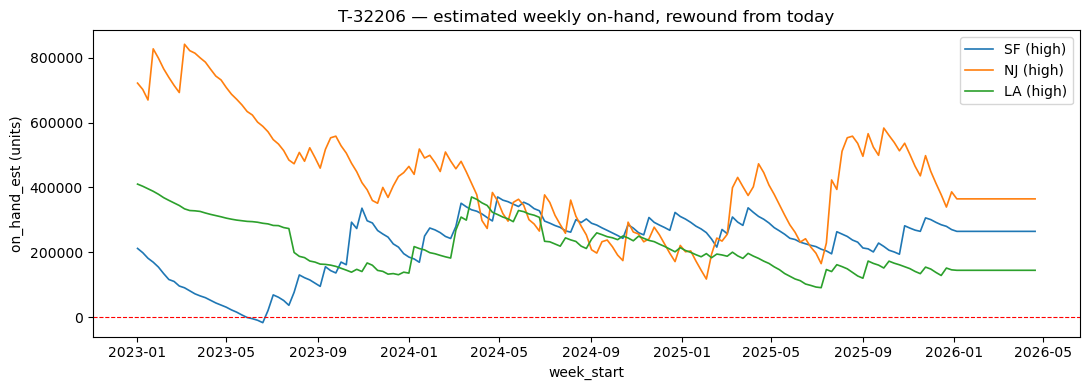


duplicate (ITEMNMBR, DC, week_start): 0
null on_hand_est: 865


In [5]:
# ---- Check 1: today's rewind should equal today's snapshot (identity) -------
today_week = weeks.max()
today_rewind = inv_weekly[inv_weekly['week_start'] == today_week].copy()
check = today_rewind.merge(
    sku_dc.rename(columns={'SKU': 'ITEMNMBR'}),
    on=['ITEMNMBR', 'DC'], how='left'
)
diff = (check['on_hand_est'] - check['today_on_hand']).abs()
print(f'today_rewind vs snapshot: max |diff| = {diff.max():.3f}  mean = {diff.mean():.3f}')
assert diff.max() < 1e-6, 'Rewind broken: today\'s estimate != snapshot'
print('identity check: PASS')

# ---- Check 2: how noisy is the rewind? --------------------------------------
print('\nmin_on_hand_est distribution (across all SKU x DC series):')
print(conf['min_est'].describe().to_string())

print('\nshare of series by severity of data gap (vs tolerance):')
conf['gap'] = -conf['min_est'] / conf['tolerance'].replace(0, np.nan)
print(f"  clean (min >= 0)               : {(conf['min_est'] >= 0).mean()*100:5.1f}%")
print(f"  minor (0 > min >= -tolerance)  : {((conf['min_est'] < 0) & (conf['confidence']=='high')).mean()*100:5.1f}%")
print(f"  low-confidence (min < -tol)    : {(conf['confidence']=='low').mean()*100:5.1f}%")

# Plot: histogram of min_est as % of today_on_hand (where today>0)
mask = conf['today_on_hand'] > 0
rel = (conf.loc[mask, 'min_est'] / conf.loc[mask, 'today_on_hand']) * 100
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(rel.clip(-200, 100), bins=60, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linestyle='-', lw=0.8)
ax.axvline(-10, color='red', linestyle='--', label='-10% tolerance')
ax.set_xlabel('min(on_hand_est) as % of today_on_hand, clipped [-200, 100]')
ax.set_ylabel('count of (SKU x DC) series')
ax.set_title('Rewind noise: how far negative does each series go vs today\'s snapshot?')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Check 3: spot-check one showcase SKU (T-32206, Tiger Balm Patch) -------
sku = 'T-32206'
for dc in ['SF', 'NJ', 'LA']:
    s = inv_weekly[(inv_weekly['ITEMNMBR'] == sku) & (inv_weekly['DC'] == dc)]
    if len(s) == 0:
        print(f'{sku} {dc}: (not in snapshot)')
        continue
    conf_val = s['confidence'].iloc[0]
    print(f'{sku} {dc} [{conf_val:>4}]: today={s["on_hand_est"].iloc[-1]:8.0f}  '
          f'min={s["on_hand_est"].min():8.0f}  max={s["on_hand_est"].max():8.0f}')

# Plot the spot-check SKU across all 3 DCs
fig, ax = plt.subplots(figsize=(11, 4))
for dc in ['SF', 'NJ', 'LA']:
    s = inv_weekly[(inv_weekly['ITEMNMBR'] == sku) & (inv_weekly['DC'] == dc)]
    if len(s):
        conf_val = s['confidence'].iloc[0]
        ax.plot(s['week_start'], s['on_hand_est'], label=f'{dc} ({conf_val})', lw=1.2)
ax.axhline(0, color='red', lw=0.8, linestyle='--')
ax.set_title(f'{sku} — estimated weekly on-hand, rewound from today')
ax.set_xlabel('week_start')
ax.set_ylabel('on_hand_est (units)')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Check 4: dup + null sanity --------------------------------------------
dups = inv_weekly.duplicated(subset=['ITEMNMBR', 'DC', 'week_start']).sum()
nulls = inv_weekly['on_hand_est'].isna().sum()
print(f'\nduplicate (ITEMNMBR, DC, week_start): {dups}')
print(f'null on_hand_est: {nulls}')

## 5. Save downstream artifact

In [6]:
inv_weekly.to_parquet(ART / 'inv_weekly.parquet')
print(f'inv_weekly  {inv_weekly.shape}  -> inv_weekly.parquet')

# Anchor + tolerance settings for downstream reference. All values stringified
# so parquet's strict column typing is happy (was mixing str dates + float nums).
meta = pd.DataFrame({
    'key':   ['anchor_today', 'rewind_start', 'tolerance_pct', 'tolerance_floor'],
    'value': [str(today.date()), str(weeks.min().date()), '0.10', '50'],
})
meta.to_parquet(ART / 'inv_rewind_meta.parquet')
print(f'meta        {meta.shape}  -> inv_rewind_meta.parquet')

inv_weekly  (37887, 5)  -> inv_weekly.parquet
meta        (4, 2)  -> inv_rewind_meta.parquet


## 6. Promote

Once validation above looks right, extract the core logic into `src/inventory.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.